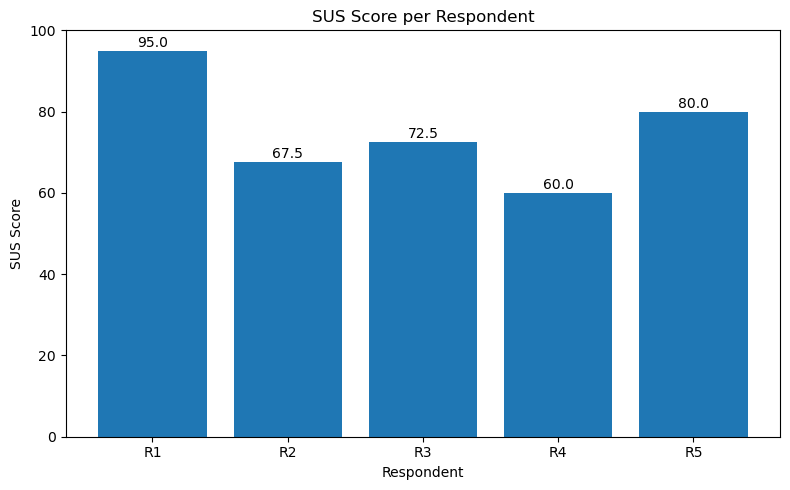

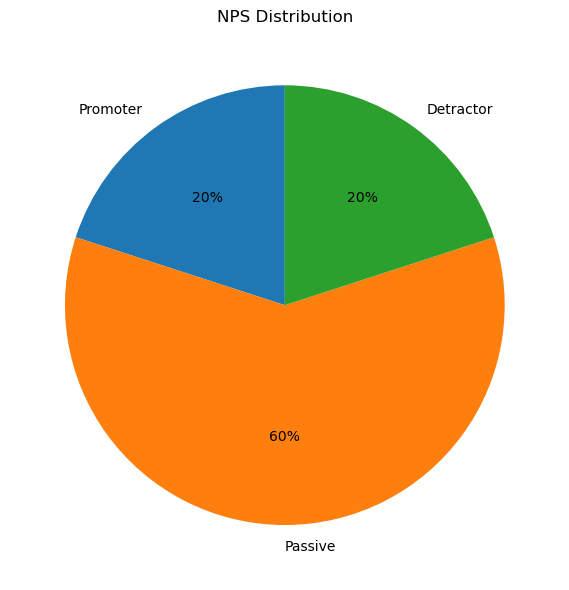

  Respondent  SUS Score  NPS NPS Category
0         R1       95.0    8      Passive
1         R2       67.5    7      Passive
2         R3       72.5   10     Promoter
3         R4       60.0    7      Passive
4         R5       80.0    6    Detractor

Average SUS Score: 75.0
NPS Score: 0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "Respondent": ["R1", "R2", "R3", "R4", "R5"],

    # NPS score per respondent
    "NPS": [8, 7, 10, 7, 6],

    # SUS answers, scale 1-5
    "SUS_1":  [5, 3, 2, 3, 3],
    "SUS_2":  [1, 2, 1, 2, 1],
    "SUS_3":  [5, 4, 5, 4, 5],
    "SUS_4":  [2, 3, 2, 3, 1],
    "SUS_5":  [5, 3, 5, 3, 5],
    "SUS_6":  [1, 2, 3, 4, 1],
    "SUS_7":  [5, 4, 4, 5, 1],
    "SUS_8":  [1, 2, 2, 3, 1],
    "SUS_9":  [4, 4, 4, 4, 3],
    "SUS_10": [1, 2, 3, 3, 1],
})


def calculate_sus(row):
    odd_items = ["SUS_1", "SUS_3", "SUS_5", "SUS_7", "SUS_9"]
    even_items = ["SUS_2", "SUS_4", "SUS_6", "SUS_8", "SUS_10"]

    odd_score = sum(row[item] - 1 for item in odd_items)
    even_score = sum(5 - row[item] for item in even_items)

    return (odd_score + even_score) * 2.5


def classify_nps(score):
    if score >= 9:
        return "Promoter"
    elif score >= 7:
        return "Passive"
    return "Detractor"


data["SUS Score"] = data.apply(calculate_sus, axis=1)
data["NPS Category"] = data["NPS"].apply(classify_nps)

average_sus = data["SUS Score"].mean()

nps_counts = (
    data["NPS Category"]
    .value_counts()
    .reindex(["Promoter", "Passive", "Detractor"], fill_value=0)
)

nps_score = (
    (nps_counts["Promoter"] / len(data)) * 100
    - (nps_counts["Detractor"] / len(data)) * 100
)


plt.figure(figsize=(8, 5))
plt.bar(data["Respondent"], data["SUS Score"])
plt.title("SUS Score per Respondent")
plt.xlabel("Respondent")
plt.ylabel("SUS Score")
plt.ylim(0, 100)

for index, value in enumerate(data["SUS Score"]):
    plt.text(index, value + 1, f"{value:.1f}", ha="center")

plt.tight_layout()
plt.savefig("sus_score_per_respondent.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 6))
plt.pie(
    nps_counts.values,
    labels=nps_counts.index,
    autopct="%1.0f%%",
    startangle=90
)
plt.title("NPS Distribution")
plt.tight_layout()
plt.savefig("nps_distribution.png", dpi=300)
plt.show()


print(data[["Respondent", "SUS Score", "NPS", "NPS Category"]])
print(f"\nAverage SUS Score: {average_sus:.1f}")
print(f"NPS Score: {nps_score:.0f}")

  Task                          Description  Successability Rate  Average Time
0   T1         Mencatat aktivitas produktif                  100            45
1   T2  Memahami perkembangan produktivitas                   80            65
2   T3       Membagikan bukti produktivitas                   80            70
3   T4        Menemukan ruang atau kelompok                   80            55
4   T5           Memperbarui informasi diri                  100            35
5   T6        Menemukan dan mengikuti event                   65            80
6   T7    Menemukan dan mengikuti challenge                   70            75
7   T8    Berinteraksi dengan pengguna lain                   65            80

Average Successability Rate: 80.0%
Average Task Completion Time: 63.1 seconds


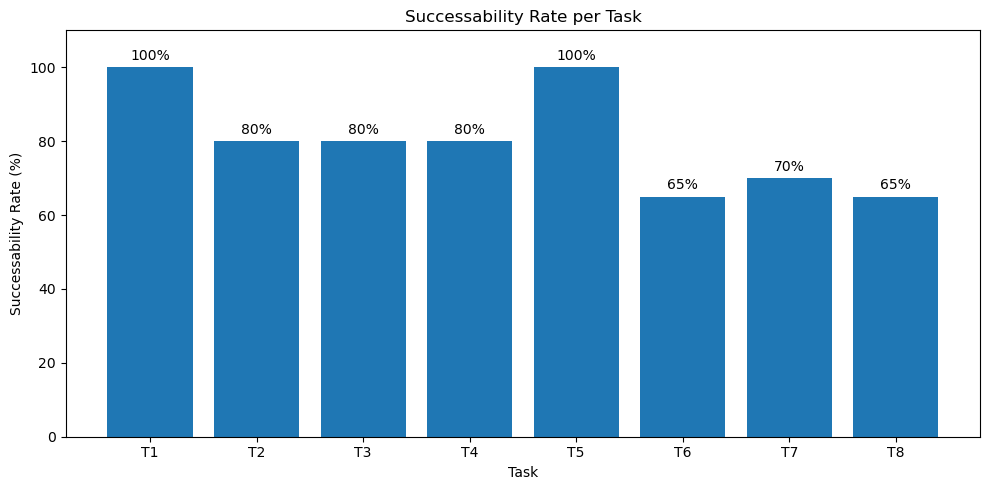

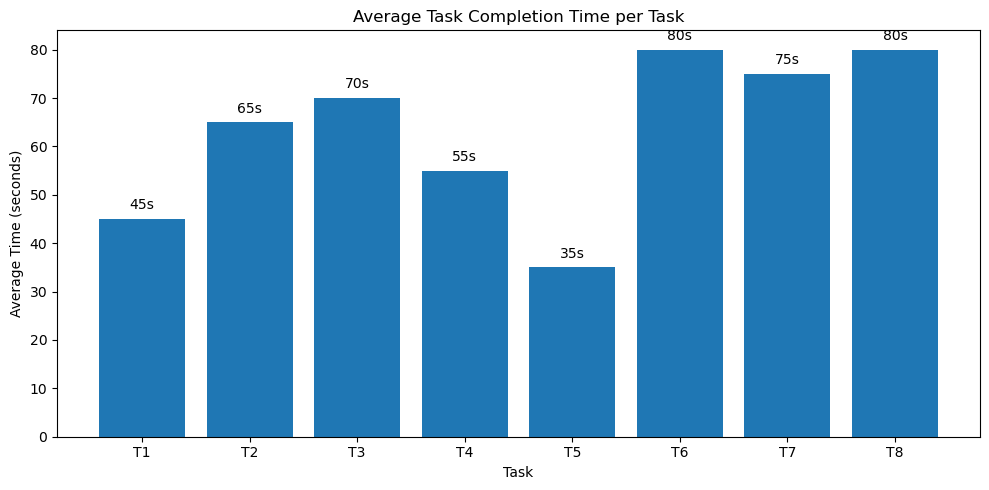

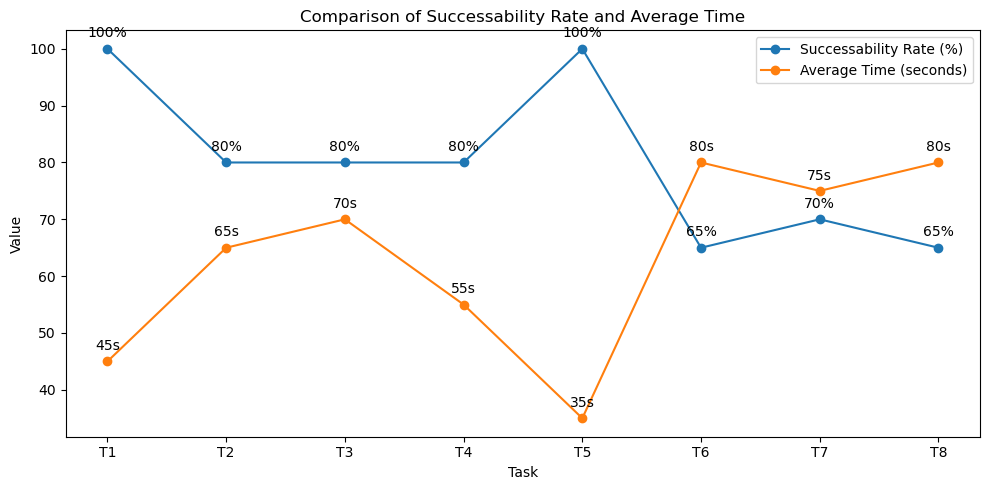

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "Task": ["T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8"],
    "Description": [
        "Mencatat aktivitas produktif",
        "Memahami perkembangan produktivitas",
        "Membagikan bukti produktivitas",
        "Menemukan ruang atau kelompok",
        "Memperbarui informasi diri",
        "Menemukan dan mengikuti event",
        "Menemukan dan mengikuti challenge",
        "Berinteraksi dengan pengguna lain",
    ],
    "Successability Rate": [100, 80, 80, 80, 100, 65, 70, 65],
    "Average Time": [45, 65, 70, 55, 35, 80, 75, 80],
})

average_successability = data["Successability Rate"].mean()
average_time = data["Average Time"].mean()

print(data)
print(f"\nAverage Successability Rate: {average_successability:.1f}%")
print(f"Average Task Completion Time: {average_time:.1f} seconds")


plt.figure(figsize=(10, 5))
plt.bar(data["Task"], data["Successability Rate"])
plt.title("Successability Rate per Task")
plt.xlabel("Task")
plt.ylabel("Successability Rate (%)")
plt.ylim(0, 110)

for index, value in enumerate(data["Successability Rate"]):
    plt.text(index, value + 2, f"{value}%", ha="center")

plt.tight_layout()
plt.savefig("successability_rate_per_task.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(data["Task"], data["Average Time"])
plt.title("Average Task Completion Time per Task")
plt.xlabel("Task")
plt.ylabel("Average Time (seconds)")

for index, value in enumerate(data["Average Time"]):
    plt.text(index, value + 2, f"{value}s", ha="center")

plt.tight_layout()
plt.savefig("average_time_per_task.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(data["Task"], data["Successability Rate"], marker="o", label="Successability Rate (%)")
plt.plot(data["Task"], data["Average Time"], marker="o", label="Average Time (seconds)")
plt.title("Comparison of Successability Rate and Average Time")
plt.xlabel("Task")
plt.ylabel("Value")
plt.legend()

for index, row in data.iterrows():
    plt.text(index, row["Successability Rate"] + 2, f"{row['Successability Rate']}%", ha="center")
    plt.text(index, row["Average Time"] + 2, f"{row['Average Time']}s", ha="center")

plt.tight_layout()
plt.savefig("successability_vs_time.png", dpi=300)
plt.show()